In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [2]:
def make_plots(y_test, y_pred, title_suffix=''):
    import matplotlib.pyplot as plt
    import numpy as np
    from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
    import os

    os.makedirs("results", exist_ok=True)

    # metrics
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    residuals = y_test - y_pred

    # create single figure with 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # --- Actual vs Predicted ---
    axes[0].plot(y_test, y_pred, alpha=0.5, s=5)
    axes[0].plot([y_test.min(), y_test.max()],
                 [y_test.min(), y_test.max()])
    axes[0].set_xlabel("Actual AQI")
    axes[0].set_ylabel("Predicted AQI")
    axes[0].set_title("Actual vs Predicted")

    # --- Residuals vs Predicted ---
    axes[1].plot(y_pred, residuals, alpha=0.5, s=5)
    axes[1].axhline(0)
    axes[1].set_xlabel("Predicted AQI")
    axes[1].set_ylabel("Residual")
    axes[1].set_title("Residuals vs Predicted")

    # --- Residual Distribution ---
    axes[2].hist(residuals, bins=100)
    axes[2].set_xlabel("Residual")
    axes[2].set_title("Residual Distribution")

    # metrics text box
    metrics_text = (
        f"R²   : {r2:.4f}\n"
        f"MSE : {mse:.2f}\n"
        f"RMSE : {rmse:.2f}\n"
        f"MAE  : {mae:.2f}"
    )

    fig.text(
        0.5, -0.05, metrics_text,
        ha="center", va="top", fontsize=11,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
    )

    fig.suptitle(f"AQI Model Performance {title_suffix}", fontsize=14)
    fig.tight_layout()

    fig.savefig(
        rf"results\model_diagnostics-{title_suffix.replace(' ','_')}.png",
        bbox_inches="tight"
    )

    plt.show()
    plt.close()


In [3]:
mldf = pd.read_csv(r'data\ml_df_processed.csv')
mldf.drop(columns=['day', 'day_of_week'], inplace=True)
mldf.head()

,brightness,acq_date,bright_t31,frp,daynight,dist_to_delhi,Latitude,Longitude,Telemetry Hourly Wind Speed (Km/Hr),tempmax,...,temp_humidity,temp_range,heat_index,conditions,AQI,weighted_distance,daynight_encoded,conditions_encoded,month,year
0,367.0,2021-04-12,299.59,52.2,D,336.028277,30.140833,74.207778,40.4,38.7,...,834.4,17.8,115.201975,Clear,226,18.262406,1.0,1.0,4,2021
1,367.0,2021-04-12,299.59,52.2,D,336.028277,30.140833,74.207778,40.4,38.7,...,834.4,17.8,115.201975,Clear,226,18.262406,1.0,1.0,4,2021
2,367.0,2021-04-12,299.59,52.2,D,336.028277,30.140833,74.207778,40.4,38.7,...,834.4,17.8,115.201975,Clear,226,18.262406,1.0,1.0,4,2021
3,367.0,2021-04-12,299.59,52.2,D,336.028277,30.140833,74.207778,40.4,38.7,...,834.4,17.8,115.201975,Clear,226,18.262406,1.0,1.0,4,2021
4,367.0,2021-04-12,299.59,52.2,D,336.028277,30.140833,74.207778,40.4,38.7,...,834.4,17.8,115.201975,Clear,226,18.262406,1.0,1.0,4,2021


In [4]:
# --- Ensure date column is datetime ---
mldf['acq_date'] = pd.to_datetime(mldf['acq_date'])

# --- Create weighted FRP column ---
mldf['weighted_frp'] = mldf['brightness'] * mldf['frp']

# --- Columns definitions ---
avg_cols = [
    'Latitude',
    'Longitude',
    'dist_to_delhi',
    'Telemetry Hourly Wind Speed (Km/Hr)',
    'windspeed'
]

sum_cols = [
    'brightness',
    'frp'
]

# --- Groupby object ---
grouped = mldf.groupby('acq_date')

# --- Aggregations ---
avg_df = grouped[avg_cols].mean()
sum_df = grouped[sum_cols].sum()

# --- Total records per day ---
count_df = grouped.size().rename('records_per_day')

# --- Weighted FRP daily sum ---
weighted_frp_sum = grouped['weighted_frp'].sum()

# --- Calculate avg weighted FRP ---
avg_weighted_frp = (weighted_frp_sum / count_df).rename('avg_wei_frp')

# --- Remaining columns → take first record of each day ---
remaining_cols = [col for col in mldf.columns if col not in (
    avg_cols + sum_cols + ['weighted_frp', 'acq_date']
)]

first_df = grouped[remaining_cols].first()

# --- Merge everything ---
newdf = pd.concat([
    avg_df,
    sum_df,
    avg_weighted_frp,
    first_df
], axis=1).reset_index()

# --- Output ---
newdf.head()


,acq_date,Latitude,Longitude,dist_to_delhi,Telemetry Hourly Wind Speed (Km/Hr),windspeed,brightness,frp,avg_wei_frp,bright_t31,...,temp_humidity,temp_range,heat_index,conditions,AQI,weighted_distance,daynight_encoded,conditions_encoded,month,year
0,2021-04-12,30.140833,74.207778,336.028277,40.4,18.4,78538.00,11170.80,19157.400,299.59,...,834.40,17.8,115.201975,Clear,226,18.262406,1.0,1.0,4,2021
1,2021-04-13,30.140833,74.207778,204.154206,28.4,18.5,62997.05,1096.86,2109.183,308.77,...,869.25,18.4,115.146444,Clear,279,11.035362,1.0,1.0,4,2021
2,2021-04-14,30.140833,74.207778,76.602201,32.0,18.4,33764.00,1193.24,4759.990,314.75,...,787.50,16.8,103.744022,Partially cloudy,214,4.163163,1.0,0.0,4,2021
3,2021-04-15,30.140833,74.207778,70.627184,32.0,19.8,33100.65,223.74,755.631,308.14,...,748.07,16.1,100.941229,Partially cloudy,235,3.567029,1.0,0.0,4,2021
4,2021-04-16,30.140833,74.207778,116.073974,28.4,37.1,9688.00,85.40,1055.300,310.36,...,1137.60,18.6,146.415782,"Rain, Partially cloudy",232,3.128679,1.0,0.0,4,2021


In [5]:
newdf.columns

Index(['acq_date', 'Latitude', 'Longitude', 'dist_to_delhi',
       'Telemetry Hourly Wind Speed (Km/Hr)', 'windspeed', 'brightness', 'frp',
       'avg_wei_frp', 'bright_t31', 'daynight', 'tempmax', 'tempmin', 'temp',
       'humidity', 'precip', 'precipcover', 'sealevelpressure',
       'tempmax_humidity', 'tempmin_humidity', 'temp_humidity', 'temp_range',
       'heat_index', 'conditions', 'AQI', 'weighted_distance',
       'daynight_encoded', 'conditions_encoded', 'month', 'year'],
      dtype='object')

In [25]:
feature_cols = [
# 'acq_date',
# 'Latitude',
# 'Longitude',
# 'dist_to_delhi',
'Telemetry Hourly Wind Speed (Km/Hr)',
# 'windspeed',
# 'brightness',
# 'frp',
# 'avg_wei_frp',
# 'bright_t31',
# 'daynight',
'tempmax',
'tempmin',
'temp',
'humidity',
'precip',
'precipcover',
'sealevelpressure',
'tempmax_humidity',
'tempmin_humidity',
'temp_humidity',
'temp_range',
'heat_index',
# 'conditions',
# 'AQI',
# 'weighted_distance',
# 'daynight_encoded',
# 'conditions_encoded',
'month',
'year'
]

In [26]:
from sklearn.ensemble import HistGradientBoostingRegressor

model = HistGradientBoostingRegressor(
    max_iter=100,
    learning_rate=0.051,
    random_state=42
)

X = newdf[feature_cols]
y = newdf['AQI']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)	
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"HistGradientBoostingRegressor Model Performance:")
print(f"R² Score: {r2}")		
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")

HistGradientBoostingRegressor Model Performance:
R² Score: 0.6346585855374156
Mean Squared Error: 3660.427121022843
Mean Absolute Error: 43.99323581542194


In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("RandomForestRegressor Model Performance:")
print("R² Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))


RandomForestRegressor Model Performance:
R² Score: 0.6566231363049437
Mean Squared Error: 3440.3599888888884
Mean Absolute Error: 43.27978947368421


In [13]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

print("XGBoost Regressor Model Performance:")
print("R² Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))

# make_plots(y_test, y_pred, title_suffix='XGBoost Regressor')

XGBoost Regressor Model Performance:
R² Score: 0.6543482542037964
Mean Squared Error: 3463.15234375
Mean Absolute Error: 43.89336013793945


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000350 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3721
[LightGBM] [Info] Number of data points in the train set: 756, number of used features: 24
[LightGBM] [Info] Start training from score 200.324074
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

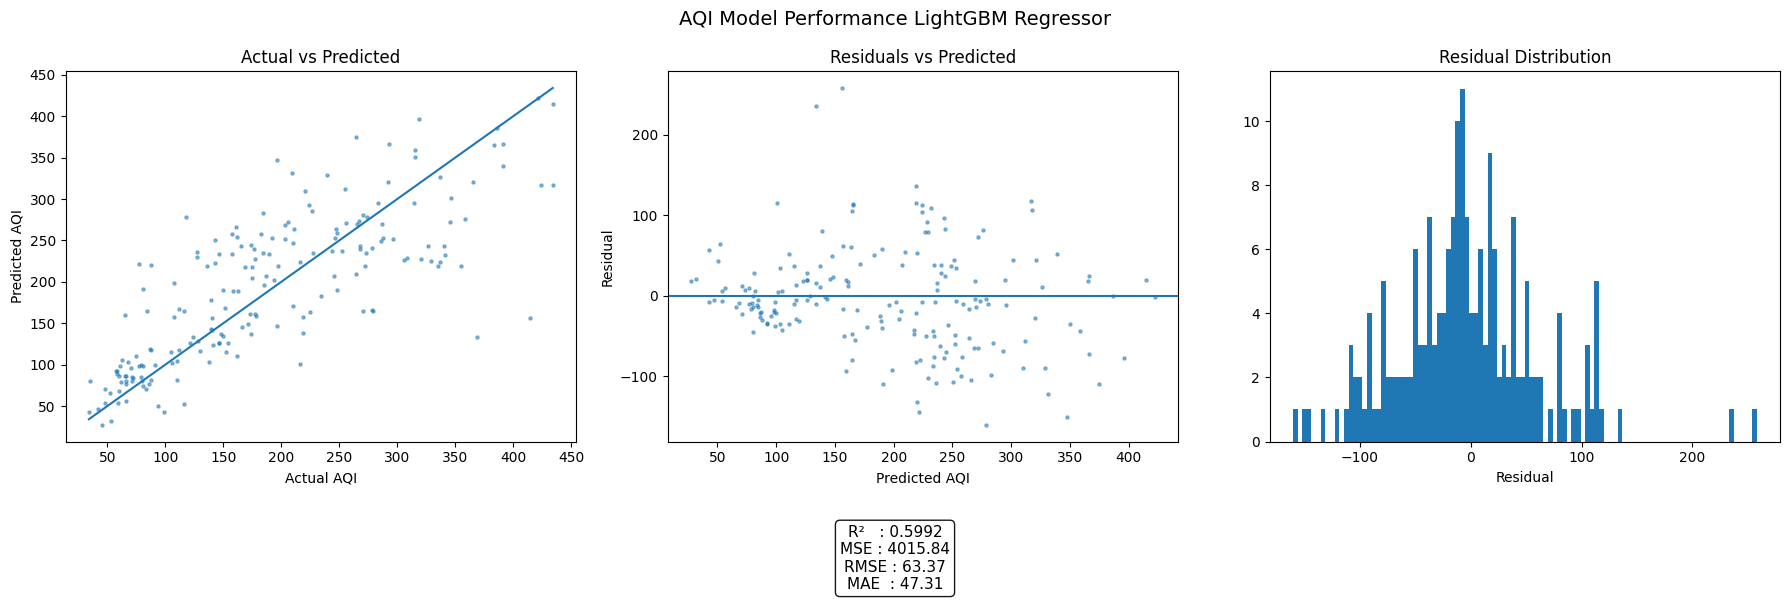

In [ ]:
from lightgbm import LGBMRegressor
import warnings
warnings.filterwarnings("ignore")

lgbm = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm.fit(X_train, y_train)
y_pred = lgbm.predict(X_test)

print("LightGBM Regressor Model Performance:")
print("R² Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))

make_plots(y_test, y_pred, title_suffix='LightGBM Regressor')


In [15]:
from catboost import CatBoostRegressor

cat = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    random_seed=42,
    verbose=False
)

cat.fit(X_train, y_train)
y_pred = cat.predict(X_test)

print("CatBoost Regressor Model Performance:")
print("R² Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))

# make_plots(y_test, y_pred, title_suffix='CatBoost Regressor')

CatBoost Regressor Model Performance:
R² Score: 0.6568531856110719
Mean Squared Error: 3438.0550798750487
Mean Absolute Error: 43.96613595280559


In [27]:
from sklearn.ensemble import ExtraTreesRegressor

etr = ExtraTreesRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

etr.fit(X_train, y_train)
y_pred = etr.predict(X_test)

print("ExtraTreesRegressor Model Performance:")
print("R² Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))

# make_plots(y_test, y_pred, title_suffix='ExtraTrees Regressor')

ExtraTreesRegressor Model Performance:
R² Score: 0.687355150938684
Mean Squared Error: 3132.4499206736837
Mean Absolute Error: 41.090336842105266


### Finetue ETR

In [ ]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

param_grid = {
    "n_estimators": [300, 500, 800, 1200],
    "max_depth": [None, 20, 40, 60],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.7, 0.9],
    "bootstrap": [False, True]
}


In [ ]:
etr = ExtraTreesRegressor(
    random_state=42,
    n_jobs=-1
)

search = RandomizedSearchCV(
    estimator=etr,
    param_distributions=param_grid,
    n_iter=40,
    scoring="r2",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)


NameError: name 'X_train' is not defined

In [ ]:
best_etr = search.best_estimator_

y_pred = best_etr.predict(X_test)

print("Tuned ExtraTreesRegressor Model Performance:")
print("R² Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))


Tuned ExtraTreesRegressor Model Performance:
R² Score: 0.6851870767696762
Mean Squared Error: 3154.172280018844
Mean Absolute Error: 41.504192872807


In [ ]:
print("Best Hyperparameters:")
print(search.best_params_)


Best Hyperparameters:
{'n_estimators': 800, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.9, 'max_depth': 60, 'bootstrap': False}


In [18]:
final_etr = ExtraTreesRegressor(
    n_estimators=800,
    max_depth=40,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features=0.7,
    bootstrap=False,
    random_state=42,
    n_jobs=-1
)

final_etr.fit(X_train, y_train)

y_pred = final_etr.predict(X_test)

print("Final ExtraTreesRegressor Model Performance:")
print("R² Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))

# make_plots(y_test, y_pred, title_suffix='Final ExtraTrees Regressor')

Final ExtraTreesRegressor Model Performance:
R² Score: 0.6875160624083869
Mean Squared Error: 3130.837717171788
Mean Absolute Error: 41.31109044506297


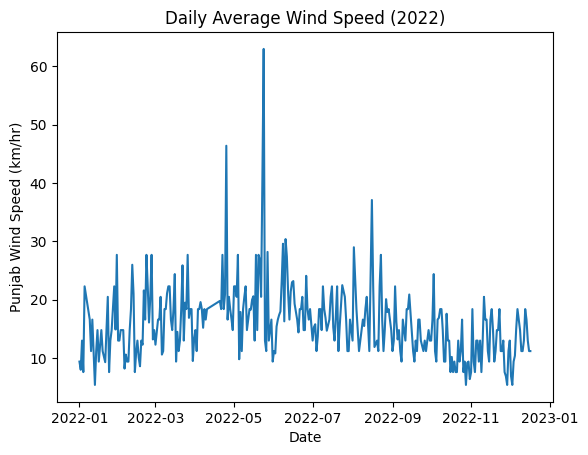

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ensure date column is datetime
newdf['acq_date'] = pd.to_datetime(newdf['acq_date'])

# filter for 2022-01 to 2023-01
mask = (newdf['acq_date'] >= '2022-01-01') & (newdf['acq_date'] < '2023-01-01')
df_2022 = newdf.loc[mask]

# compute daily average wind speed
daily_wind = df_2022.groupby('acq_date')['windspeed'].mean().reset_index()

# plot
plt.figure()
plt.plot(daily_wind['acq_date'], daily_wind['windspeed'])
plt.xlabel('Date')
plt.ylabel('Punjab Wind Speed (km/hr)')
plt.title('Daily Average Wind Speed (2022)')
plt.show()


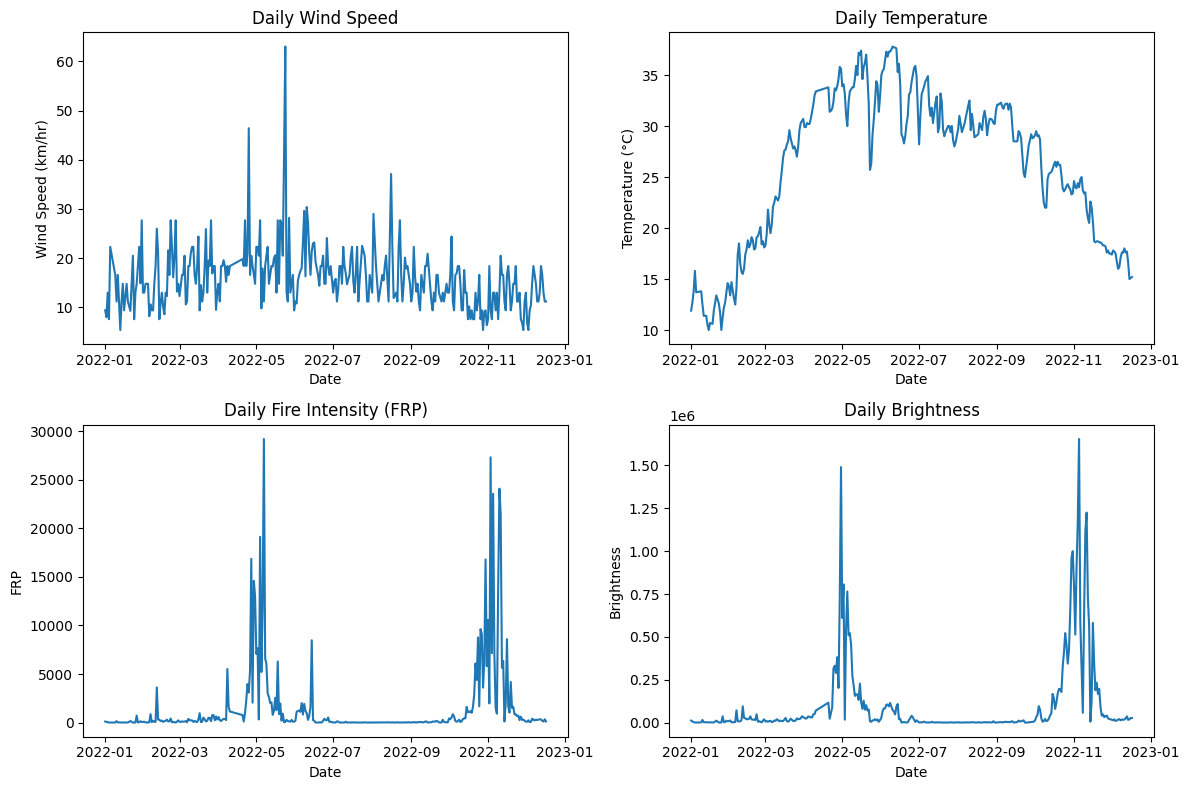

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ensure date column is datetime
newdf['acq_date'] = pd.to_datetime(newdf['acq_date'])

# filter for 2022-01 to 2023-01
mask = (newdf['acq_date'] >= '2022-01-01') & (newdf['acq_date'] < '2023-01-01')
df_2022 = newdf.loc[mask]

# daily aggregates
daily = df_2022.groupby('acq_date').agg({
    'windspeed': 'mean',
    'temp': 'mean',
    'frp': 'mean',        # fire intensity
    'brightness': 'mean'
}).reset_index()

# 2x2 grid
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(daily['acq_date'], daily['windspeed'])
plt.title('Daily Wind Speed')
plt.xlabel('Date')
plt.ylabel('Wind Speed (km/hr)')

plt.subplot(2, 2, 2)
plt.plot(daily['acq_date'], daily['temp'])
plt.title('Daily Temperature')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')

plt.subplot(2, 2, 3)
plt.plot(daily['acq_date'], daily['frp'])
plt.title('Daily Fire Intensity (FRP)')
plt.xlabel('Date')
plt.ylabel('FRP')

plt.subplot(2, 2, 4)
plt.plot(daily['acq_date'], daily['brightness'])
plt.title('Daily Brightness')
plt.xlabel('Date')
plt.ylabel('Brightness')

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

selected_params = {
    "n_estimators": final_etr.n_estimators,
    "max_depth": final_etr.max_depth,
    "min_samples_split": final_etr.min_samples_split,
    "min_samples_leaf": final_etr.min_samples_leaf,
    "max_features": final_etr.max_features,
    "bootstrap": final_etr.bootstrap
}

params_df = pd.DataFrame(
    list(selected_params.items()),
    columns=["Hyperparameter", "Value"]
)

params_df


,Hyperparameter,Value
0,n_estimators,800
1,max_depth,40
2,min_samples_split,5
3,min_samples_leaf,2
4,max_features,0.7
5,bootstrap,False


In [ ]:
import pandas as pd

results_df = pd.DataFrame({
    "Model": [
        "ExtraTreesRegressor",
        "CatBoostRegressor",
        "XGBoostRegressor",
        "RandomForestRegressor",
        "HistGradientBoostingRegressor"
    ],
    "R2_Score": [
        0.6831242873012039,
        0.6572122068134614,
        0.6615795493125916,
        0.6352244668657696,
        0.6283975679689506
    ],
    "MSE": [
        3174.8397713473687,
        3434.457976195518,
        3390.70068359375,
        3654.7574452631575,
        3723.157481188886
    ],
    "MAE": [
        41.24135789473684,
        43.63326870544004,
        43.60285186767578,
        44.33259649122807,
        45.350964233133304
    ]
})

results_df = results_df.round(3)
results_df.head()


,Model,R2_Score,MSE,MAE
0,ExtraTreesRegressor,0.683,3174.840,41.241
1,CatBoostRegressor,0.657,3434.458,43.633
2,XGBoostRegressor,0.662,3390.701,43.603
3,RandomForestRegressor,0.635,3654.757,44.333
4,HistGradientBoostingRegressor,0.628,3723.157,45.351


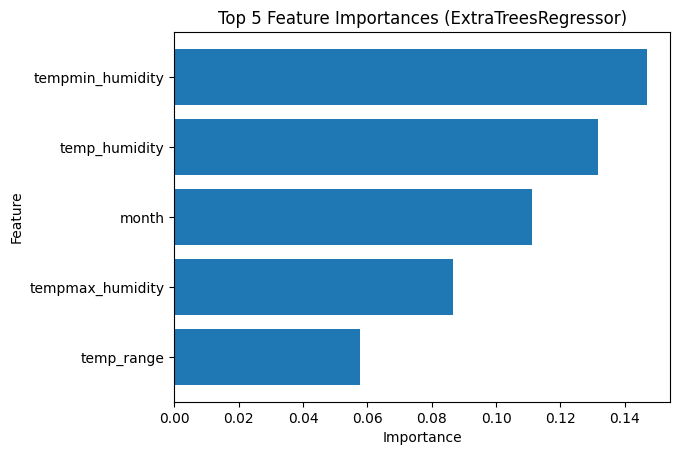

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Get feature importances
importances = final_etr.feature_importances_

# If X_train is a DataFrame, use column names
feature_names = X_train.columns

# Create DataFrame
fi_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Select top 5 features
top5_fi = fi_df.sort_values("Importance", ascending=False).head(5)

# Plot
plt.figure()
plt.barh(top5_fi["Feature"], top5_fi["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 5 Feature Importances (ExtraTreesRegressor)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


In [17]:
mldf.describe().loc[['mean', 'min', 'max']].drop(
    columns=['acq_date', 'conditions_encoded', 'tempmax_humidity', 'tempmin_humidity', 'Latitude', 'Longitude', 'tempmax', 'tempmin', 'daynight_encoded'
                                                          ]).round(2).T

,mean,min,max
brightness,339.79,293.78,367.00
bright_t31,305.64,266.66,325.52
frp,5.86,0.20,71.26
dist_to_delhi,164.81,11.50,718.74
Telemetry Hourly Wind Speed (Km/Hr),4.26,0.00,260.00
temp,27.59,9.30,39.50
humidity,50.92,17.80,99.00
precip,0.25,0.00,203.05
precipcover,0.22,0.00,45.83
windspeed,14.43,5.40,63.00
